# Лабораторная работа №1: Первичное исследование и оценка качества данных (продолжение)

### Загрузка данных


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/StudentPerformanceFactors.csv')

### Иследование данных

In [2]:
print("Первые 5 строк данных:")
print(df.head())
print("Информация о данных:")
print(df.info())
print("Уникальные значения для столбцов:")
for column in df.columns:
    print(f"\n{column}:")
    print(f"Примеры значений: {df[column].unique()}")
    print(f"Количество уникальных значений: {df[column].nunique()}")

Первые 5 строк данных:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Qual

## 1. Типы признаков и шкалы измерения
### Задание 1
### 1.1 Тип шкалы:
#### Номинальная
1. Extracurricular_Activities - Yes/No без порядка
2. Internet_Access - Yes/No без порядка
3. School_Type - Public/Private без порядка
4. Learning_Disabilities - Yes/No без порядка
5. Gender - Male/Female без порядка
#### Порядковая
1. Parental_Involvement - Low < Medium < High
2. Access_to_Resources - Low < Medium < High
3. Motivation_Level - Low < Medium < High
4. Family_Income - Low < Medium < High
5. Teacher_Quality - Low < Medium < High
6. Peer_Influence - Negative < Neutral < Positive
7. Parental_Education_Level - High School < College < Postgraduate
8. Distance_from_Home - Near < Moderate < Far
#### Шкала отношений / абсолютная
1. Hours_Studied - Количество часов, 0 = отсутствие учебы(естественная
точка отсчета)
2. Attendance - Процент посещаемости, 0 = отсутствие посещений
3. Sleep_Hours - Количество часов сна, 0 = отсутствие сна
4. Previous_Scores - Баллы, 0 = отсутствие знаний или не выболнение требований
5. Tutoring_Sessions - Колличество занятий с репетитором, 0 = отсутствие занятий
6. Physical_Activity - Уровень активности, 0 = отсутствие активности
7. Exam_Score - Баллы на экзамене, 0 = отсутствие правильных ответов или не явка
### 1.2 Ответы на вопросы:
#### Exam_Score (шкала отношений)
1. Имеет смысл вычислять среднее
2. Имеет смысл вычислять медиану
3. Имеет смысл вычислять моду
#### Parental_Involvement (порядковая)
1. Не имеет смысла вычислять среднее, так как если пронумеровать категории Low=1, Medium=2, High=3 среднее ничего не даст, к тому же может быть не целой
2. Не имеет смысла вычислять медиану, так как мы не знаем расстояния между категориями
3. Имеет смысл вычислить моду
#### Exam_Score (шкала отношений)

## Exam_Score (шкала отношений)

| Агрегат | Математически                                                          | Методологически | Обоснование |
|---------|------------------------------------------------------------------------|-----------------|-------------|
| Сумма | да `df['Exam_Score'].sum()`                                            | да              | Баллы можно суммировать, суммарный результат имеет смысл |
| Среднее | да `df['Exam_Score'].mean()`                                           | да              | Имеет смысл "средний балл" группы студентов |
| Медиана | да `df['Exam_Score'].median()`                                         | да              | "Центральный балл" информативен|
| Мода | да `df['Exam_Score'].mode()`                                           | да              | "Самый частый балл" показывает наиболее распространенный результат |
| Стандартное отклонение | да `df['Exam_Score'].std()`                                            | да              | Разброс баллов измеряем, показывает вариативность результатов |
| Дисперсия | да `df['Exam_Score'].var()`                                            | да              | Квадрат отклонений имеет смысл для анализа распределения |
| Минимум | да `df['Exam_Score'].min()`                                            | да              | Границы диапазона важны, показывает наихудший результат |
| Максимум | да `df['Exam_Score'].max()`                                            | да              | Границы диапазона важны, показывает наилучший результат |
| Процентили | да `df['Exam_Score'].quantile(0.25)`                                   | да              | Доли распределения значимы, показывают положение в выборке |
| Коэффициент вариации | да `(df['Exam_Score'].std()/df['Exam_Score'].mean())*100`              | да              | Относительный разброс, позволяет сравнивать разные группы |
| Размах | да `df['Exam_Score'].max() - df['Exam_Score'].min()`                   | да              | Полный диапазон значений |
| Межквартильный размах | да `df['Exam_Score'].quantile(0.75) - df['Exam_Score'].quantile(0.25)` | да              | Разброс центральной части данных |

## Parental_Involvement (порядковая шкала)

| Агрегат | Математически              | Методологически | Обоснование                         |
|---------|----------------------------|-----------------|-------------------------------------|
| Сумма | нет                        | нет             | Категории Low/Medium/High нельзя суммировать |
| Среднее | да (только с кодированием) | нет             | Не имеет смысла "средняя категория", результат неинтерпретируем |
| Медиана | да                         | нет             | Мы не знаем расстояния между категориями |
| Мода | да                         | да              | Полностью информативна              |
| Стандартное отклонение | нет                        | нет             | Разброс категорий не измеряется таким способом |
| Дисперсия | нет                        | нет             | Квадраты отклонений бессмысленны для категорий |
| Минимум | да                         | да              | Самая низкая категория (Low)        |
| Максимум | да                         | да              | Самая высокая категория (High)      |
| Процентили | да                         | нет             | Категория на позиции процентиля условна |
| Частота | да                         | да              | Количество наблюдений в каждой категории информативно |
| Процентное распределение | да                         | да              | Доли категорий полностью корректны и информативны |
| Накопительные проценты | да                         | да              | Процент наблюдений до определенной категории включительно |

## 2 Пропуски и их природа (MCAR / MAR / MNAR)
### Задание 2. Диагностика типа пропусков
#### 2.1 Три альтернативные гипотезы
1. MCAR  – пропуски в Teacher_Quality возникают совершенно случайно, не связаны ни с какими наблюдаемыми или ненаблюдаемыми переменными.
2. MAR  – пропуски в Teacher_Quality зависят от других наблюдаемых переменных в данных (например, от School_Type, Family_Income), но не от самого значения Teacher_Quality.
3. MNAR  – пропуски в Teacher_Quality зависят от самого значения этого признака (например, низкое качество не фиксируется) или от ненаблюдаемых факторов.
#### 2.2 Проверка гипотез
##### Что может подтвердить:
1. Если пропуски распределены равномерно по всем группам , то это может быть MCAR.
2. Если пропуски связаны с другими наблюдаемыми переменными (например, чаще встречаются в государственных школах), то это MAR.
3. Если среди наблюдаемых значений почти нет Low, то возможно его скрывают умышленно и это может быть MNAR

### Проверка для MCAR

In [3]:
for feature in ['School_Type', 'Family_Income', 'Gender']:
    crosstab = pd.crosstab(df[feature], df['Teacher_Quality'], normalize='index') * 100
    print(f"{feature}: {crosstab}")

School_Type: Teacher_Quality       High        Low     Medium
School_Type                                     
Private          30.211480   9.768379  60.020141
Public           29.650011  10.191503  60.158486
Family_Income: Teacher_Quality       High        Low     Medium
Family_Income                                   
High             28.764940  10.517928  60.717131
Low              30.329421  10.715638  58.954941
Medium           29.813900   9.191037  60.995063
Gender: Teacher_Quality       High        Low     Medium
Gender                                          
Female           30.039956   9.880131  60.079913
Male             29.661017  10.195975  60.143008


### Проверка для MAR

In [4]:
for feature in ['School_Type', 'Family_Income', 'Gender']:
    crosstab = pd.crosstab(df[feature], df['Teacher_Quality'], normalize='index') * 100
    print(f"{feature}: {crosstab}")

School_Type: Teacher_Quality       High        Low     Medium
School_Type                                     
Private          30.211480   9.768379  60.020141
Public           29.650011  10.191503  60.158486
Family_Income: Teacher_Quality       High        Low     Medium
Family_Income                                   
High             28.764940  10.517928  60.717131
Low              30.329421  10.715638  58.954941
Medium           29.813900   9.191037  60.995063
Gender: Teacher_Quality       High        Low     Medium
Gender                                          
Female           30.039956   9.880131  60.079913
Male             29.661017  10.195975  60.143008


### Проверка для MNAR

In [5]:
if df['Teacher_Quality'].notna().any():
    value_counts = df['Teacher_Quality'].value_counts(normalize=True) * 100
    print(value_counts)

total_rows = 6607
missing_pct = 1.2
observed_low_pct = 10.1


missing_count = total_rows * missing_pct / 100
observed_low_count = total_rows * observed_low_pct / 100

print(f"Пропущенных строк: {missing_count:.0f}")
print(f"Строк с Low: {observed_low_count:.0f}")
print(f"Максимум возможных Low (если все пропуски=Low): {observed_low_count + missing_count:.0f}")

Teacher_Quality
Medium    60.116404
High      29.820800
Low       10.062797
Name: proportion, dtype: float64
Пропущенных строк: 79
Строк с Low: 667
Максимум возможных Low (если все пропуски=Low): 747


### Задание 3. Индикатор пропуска как источник информации
1. Объясните, в каком случае сам факт пропуска несёт информацию.

Сам факт пропуска несёт информацию, когда данные пропущены не случайно:
###### MAR — пропуски объясняются другими наблюдаемыми переменными
###### MNAR — пропуски связаны с самим пропущенным значением

2. Почему значимость индикатора в модели - это сигнал о неправильной или грубой
импутации?
###### Мы создаем шум: На самом деле группа с пропусками могла иметь другое распределение
###### Мы теряем важный сигнал: Модель "говорит" нам, что сам факт пропуска важен для предсказания, а мы вместо него поставили среднее значение
3. Приведите пример признака, для которого индикатор пропуска:
###### полезен:
Parental_Education_Level. Можно предположить что это пропуск MAR, тогда индикатор может быть полезен, для отличия реальных значений от заполненных искусственно
###### бесполезен:
Teacher_Quality. Так как, это MCAR — пропуски распределены равномерно:
###### опасен:
Exam_Score (если бы в нем были пропуски). Может возникнуть связь, если балл пропущен -> студент не явился
### 3 Выбросы
### Задание 4. Выброс - это ошибка или сигнал?

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

Границы для выбросов (IQR метод):
Нижняя граница: 59.00
Верхняя граница: 75.00
Количество выбросов: 104
Процент выбросов: 1.57%

Топ-5 максимальных значений Exam_Score:
1525    101
94      100
2425     99
3579     99
4192     98
Name: Exam_Score, dtype: int64

Топ-5 минимальных значений Exam_Score:
1101    55
5507    56
2880    57
3543    57
5719    57
Name: Exam_Score, dtype: int64


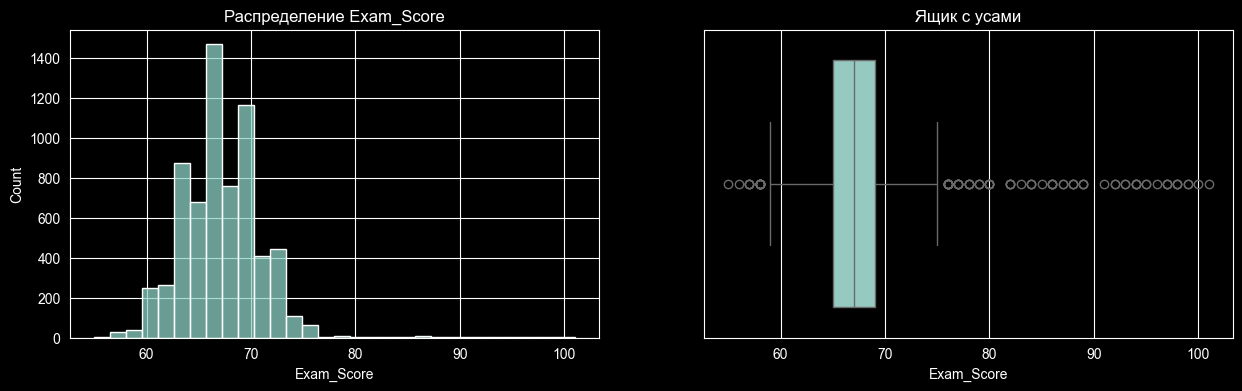

In [6]:
print(df['Exam_Score'].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(df['Exam_Score'], bins=30, ax=axes[0])
axes[0].set_title('Распределение Exam_Score')

sns.boxplot(x=df['Exam_Score'], ax=axes[1])
axes[1].set_title('Ящик с усами')

Q1 = df['Exam_Score'].quantile(0.25)
Q3 = df['Exam_Score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Exam_Score'] < lower_bound) | (df['Exam_Score'] > upper_bound)]
print(f"\nГраницы для выбросов (IQR метод):")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Количество выбросов: {len(outliers)}")
print(f"Процент выбросов: {len(outliers)/len(df)*100:.2f}%")


print("\nТоп-5 максимальных значений Exam_Score:")
print(df['Exam_Score'].nlargest(5))

print("\nТоп-5 минимальных значений Exam_Score:")
print(df['Exam_Score'].nsmallest(5))

1. Реальные причины которые могут объяснить значение 101:
###### Ошибка ввода данных
###### Бонусные баллы
###### Особая шкала оценивания
2. Худшее решение для анализа:
###### Оставить без изменений. Так как модели увидят значение вне допустимого диапазона. Линейные модели сместятся. Метрики исказятся.

### 4 Статистики
### Задание 5. Преобразование или винзоризация?

Text(0.5, 1.0, 'Распределение Tutoring_Sessions')

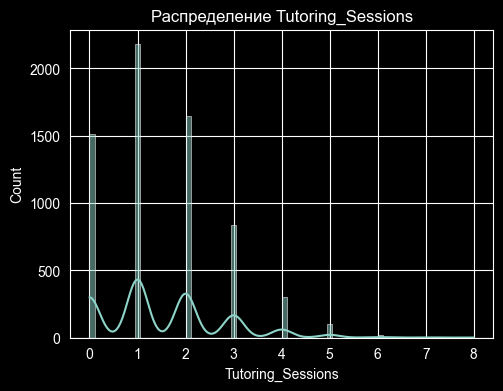

In [7]:
column = 'Tutoring_Sessions'
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df[column], kde=True)
plt.title(f'Распределение {column}')

1. Предпочтительнее:
##### логарифмирование. Когда сильная правосторонняя асимметрия, экспоненциальный рост, все значения > 0
##### корень. Когда умеренная асимметрия, счетные данные, есть нули
##### винзоризация. отдельные экстремальные выбросы, хотим сохранить исходную шкалу, выбросы — вероятные ошибки



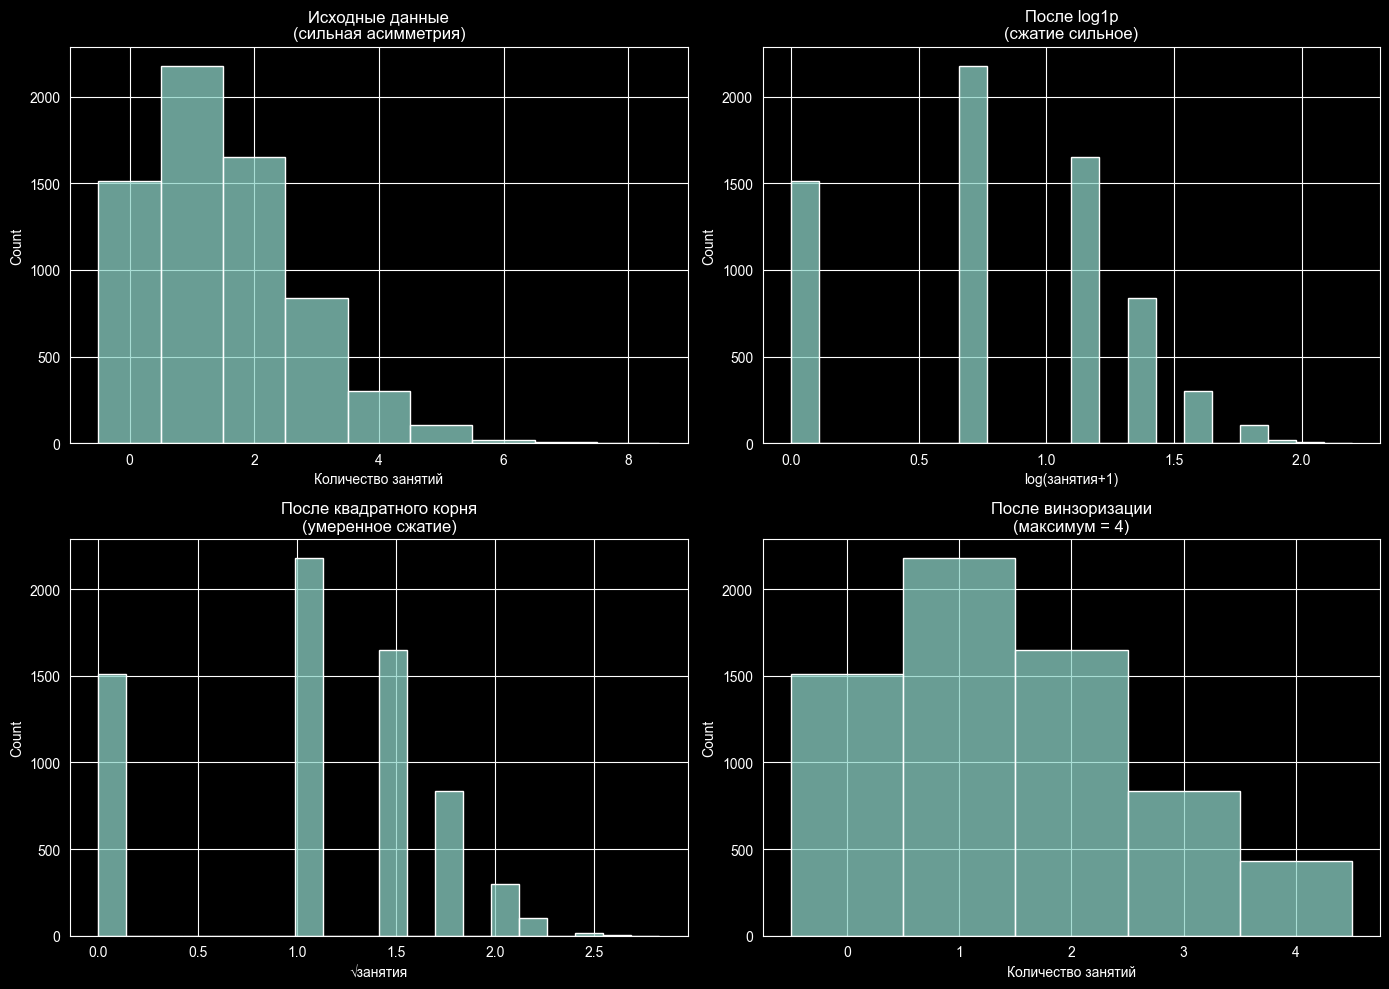

In [8]:
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Tutoring_Sessions'], bins=9, discrete=True, ax=axes[0,0])
axes[0,0].set_title('Исходные данные\n(сильная асимметрия)')
axes[0,0].set_xlabel('Количество занятий')


sns.histplot(np.log1p(df['Tutoring_Sessions']), bins=20, ax=axes[0,1])
axes[0,1].set_title('После log1p\n(сжатие сильное)')
axes[0,1].set_xlabel('log(занятия+1)')


sns.histplot(np.sqrt(df['Tutoring_Sessions']), bins=20, ax=axes[1,0])
axes[1,0].set_title('После квадратного корня\n(умеренное сжатие)')
axes[1,0].set_xlabel('√занятия')

upper = df['Tutoring_Sessions'].quantile(0.95)
df_winsor = df['Tutoring_Sessions'].clip(upper=upper)
sns.histplot(df_winsor, bins=9, discrete=True, ax=axes[1,1])
axes[1,1].set_title(f'После винзоризации\n(максимум = {int(upper)})')
axes[1,1].set_xlabel('Количество занятий')

plt.tight_layout()
plt.show()

2. Влияние на:
##### интерпретируемость:
###### логарифмирование - сильное
###### корень - сильное
###### винзоризация - низкое
##### линейные модели:
###### логарифмирование - низкая
###### корень - низкая
###### винзоризация - низкая
##### визуализация распределения:
###### логарифмирование - сильное
###### корень - сильное
###### винзоризация - среднее

### Задание 6. Средние, которые вводят в заблуждение

In [9]:
from scipy import stats

data = df['Tutoring_Sessions']

arith_mean = data.mean()
print(f"Арифметическое среднее: {arith_mean:.4f}")

median_val = data.median()
print(f"Медиана: {median_val:.4f}")

geo_mean_plus1 = stats.gmean(data + 1) - 1
print(f"Геометрическое (смещенное на +1): {geo_mean_plus1:.4f}")

Арифметическое среднее: 1.4937
Медиана: 1.0000
Геометрическое (смещенное на +1): 1.1975


1. Значения разнятся
2. Они различаются из-за асимметрии (много студентов с 1-2, мало с 4-8), выбрасами (студенты с 4-8 занятиями тянут арифметичесое вверх)
3. Лучше отражает типичное значение медиана так как она не чувствительна к выбросам и показывает реальный центр распределения
### 5 Визуализация как инструмент мышления
### Задание 7. Неправильная диаграмма

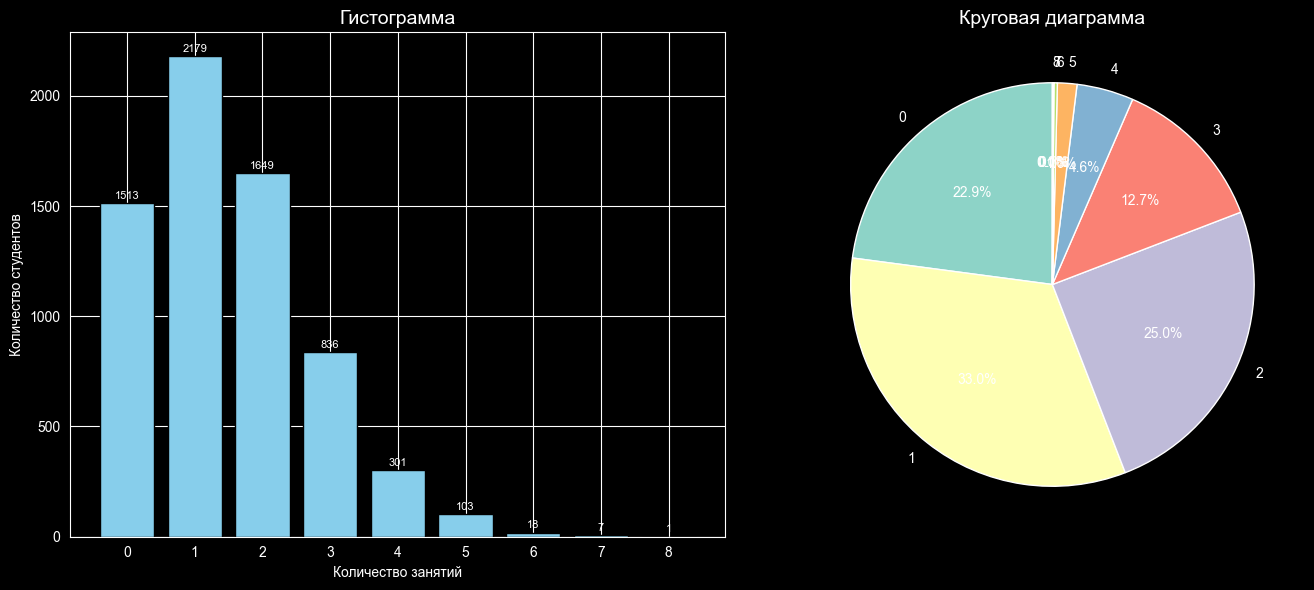

In [10]:
data = df['Tutoring_Sessions']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


counts = data.value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
axes[0].set_title('Гистограмма', fontsize=14)
axes[0].set_xlabel('Количество занятий')
axes[0].set_ylabel('Количество студентов')
axes[0].set_xticks(range(0, 9))


for i, (x, y) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(x, y + 20, str(y), ha='center', fontsize=8)


axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Круговая диаграмма', fontsize=14)

plt.tight_layout()
plt.show()

#### Доказательство: Круговая диаграмма хуже Гистограммы для данных Tutoring_Sessions
1. Слишком много категорий (9) для круговой диаграммы, оптимально от 2 до 5
2. Мелкие сектора становятся нечитаемыми (8-6)
3. Потеря информации об асимметрии
4.  Невозможность точного сравнения (0 и 2)
#### Описание
##### какую информацию он бы исказил
1. Асимметрия распределения
2. Выбросы
3. Порядок значений
##### какой неверный вывод мог бы сделать зритель
Студентов с 5+ занятиями практически нет хотя их 129
### Задание 8. Одна и та же информация - разные графики
#### График 1: Диаграмма рассеяния

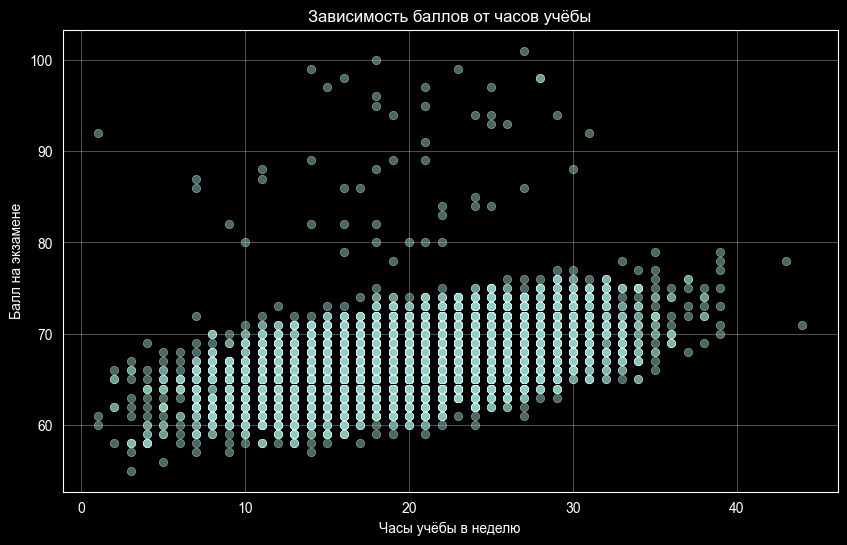

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Hours_Studied', y='Exam_Score', alpha=0.5)
plt.title('Зависимость баллов от часов учёбы')
plt.xlabel('Часы учёбы в неделю')
plt.ylabel('Балл на экзамене')
plt.grid(True, alpha=0.3)
plt.show()

подчёркивает:
1. Форму зависимости — видно, линейная она или нет
2. Плотность распределения — где точек больше, там гуще
3. Выбросы — точки, далеко отстоящие от основного облака
4. Границы значений — минимальные и максимальные значения по обеим осям
5. Кластеры — если есть отдельные группы точек
#### График 2: Ящик с усами

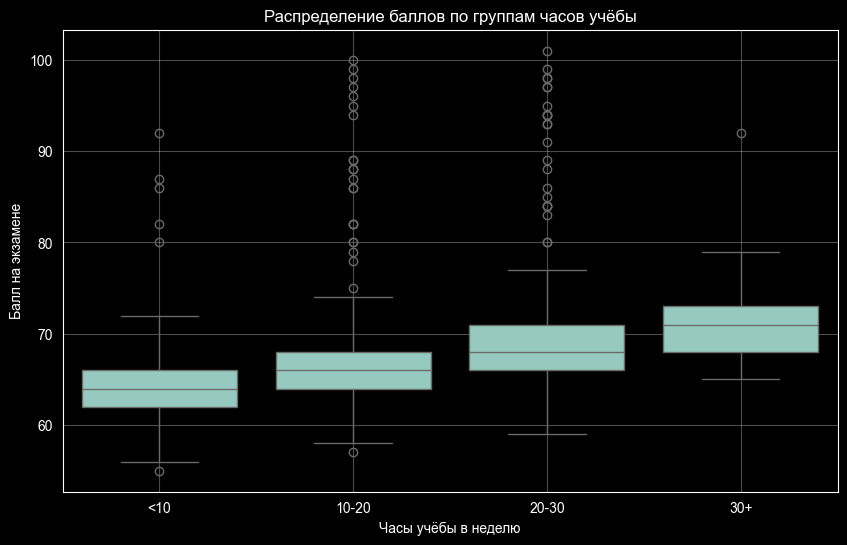

In [12]:

df['Hours_Category'] = pd.cut(df['Hours_Studied'],
                               bins=[0, 10, 20, 30, 50],
                               labels=['<10', '10-20', '20-30', '30+'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Hours_Category', y='Exam_Score')
plt.title('Распределение баллов по группам часов учёбы')
plt.xlabel('Часы учёбы в неделю')
plt.ylabel('Балл на экзамене')
plt.grid(True, alpha=0.3)
plt.show()

подчёркивает:
1. Медианные значения
2. Разброс внутри группы — высота ящика (IQR)
3. Выбросы в каждой группе — точки за усами
4. Сравнение групп — удобно сравнивать медианы и разброс

#### Гипотезы, которые легче заметить на диаграмме рассеяния:
1. Существует нелинейная зависимость - если точки образуют кривую (например, параболу)
2. Есть кластеры студентов

#### Гипотезы, которые легче заметить на ящиках с усами:
1. Студенты, которые учатся больше 30 часов, имеют более стабильные результаты
2. Медианный балл растёт с увеличением часов учёбы - Сравнение медиан по группам очень наглядно
